In [1]:
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

import torch

device = torch.device('cpu')#torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32

# Generate training data

In [2]:
from orbitflows import generate_sho_orbits
from orbitflows.dynamics import H_sho
import torch

omega_guess = 1.5
t_end = 2 * torch.pi / omega_guess
n_steps = 100
r_bounds = torch.tensor([0.15, 0.75])
guess_ps, true_aa = generate_sho_orbits(n_orbits=10, omega=omega_guess, t_end=t_end, 
                    n_steps=n_steps, r_bounds=r_bounds)
guess_ps = guess_ps.to(device=device, dtype=dtype)
true_aa = true_aa.to(device=device, dtype=dtype)

The orbits are foliated ovals in phase-space and line of constant action in action-angle coordinates.

Text(0.5, 1.0, 'Action-angle space')

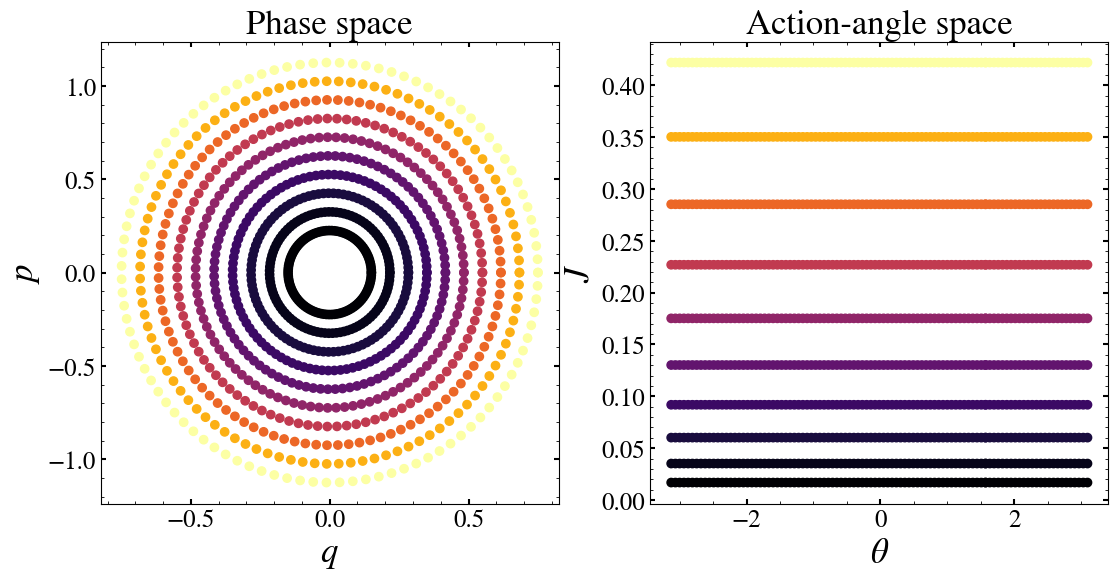

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
Htoy = H_sho(guess_ps, omega=omega_guess)

ax[0].scatter(guess_ps[..., 0], guess_ps[..., 1], c=Htoy, cmap='inferno')
ax[0].set_xlabel('$q$', fontsize=25)
ax[0].set_ylabel('$p$', fontsize=25)
ax[0].set_title('Phase space', fontsize=25)

ax[1].scatter(true_aa[..., 0], true_aa[..., 1], c=Htoy, cmap='inferno')
ax[1].set_xlabel('$\\theta$', fontsize=25)
ax[1].set_ylabel('$J$', fontsize=25)
ax[1].set_title('Action-angle space', fontsize=25)

Energy, $H_{\text{target}}$, is ***not*** constant along orbits when evaluated in the target potential. The energy goes above and below the true value in different parts of the orbit.

/geir_data/scr/gabrielspace/orbitflows/src/dynamics/potentials.py:136: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  R = torch.tensor(R)



Text(0, 0.5, '$H_{\\text{target}}$')

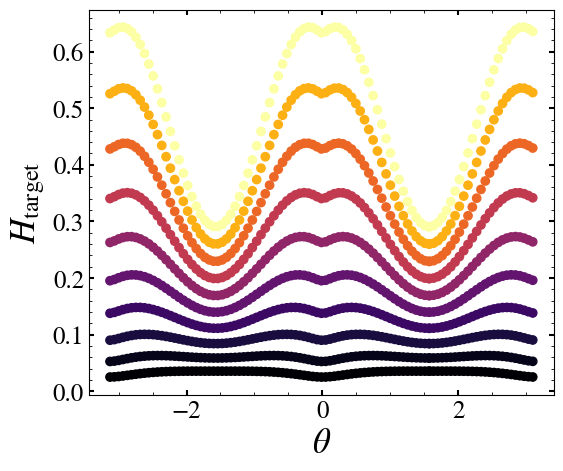

In [4]:
from orbitflows.dynamics import H, MWPotential2014_1D

targetPotential = MWPotential2014_1D
Htarget = H(guess_ps, targetPotential) # the energy calculated in the target potential

plt.figure(figsize=(6, 5))
plt.scatter(true_aa[...,0], Htarget, c=Htoy, cmap='inferno')
plt.xlabel('$\\theta$', fontsize=25)
plt.ylabel('$H_{\\text{target}}$', fontsize=25)

# Building a Model

The following demonstrates how to build a flow-based ML model that learns $(q, p) \leftrightarrow (\theta, J)$ by constructing a canonical transformation where $H_{\text{target}}$ is conserved along individual orbits.

In [5]:
from orbitflows import (HamiltonianMappingModel, 
                        SymplecticCouplingLayer, 
                        SimpleNNConditioner)
from functools import partial
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Define a learning rate scheduler
epsilon_float64 = torch.finfo(torch.float64).eps
scheduler = partial(ReduceLROnPlateau, mode='min', patience=50, 
                      factor=0.9, threshold=1e-7, threshold_mode='rel', 
                      eps=epsilon_float64)
# Define the model
model = HamiltonianMappingModel(
    targetPotential=targetPotential,
    input_dim=2, 
    n_layers=10, 
    omega=omega_guess,
    layer_class=SymplecticCouplingLayer,
    conditioner=SimpleNNConditioner,
    conditioner_args={
        'num_layers' : 5,
        'projection_dims' : 64,
        'activation':torch.nn.ReLU,
        'include_bias':True},
    optimizer=torch.optim.Adam, 
    scheduler=scheduler
)

`HamiltonianMappingModel` learns the transformation by deforming
toy orbits (tori) in phase-space. There is another model, `TorusMappingModel`, that learns the transformation by deforming orbits in action-angle space.

# Training the Model

In [6]:
epochs = 1000
model.train(guess_ps, epochs, lr=1e-3)

Training:   0%|          | 1/1000 [00:00<01:54,  8.71it/s, loss=1.56, lr=0.001, mean_max_error=-0.641, mean_mean_error=-1.03]

/geir_data/scr/gabrielspace/orbitflows/src/dynamics/potentials.py:136: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  R = torch.tensor(R)

/geir_data/scr/gabrielspace/miniforge3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1340: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  current = float(metrics)



Training: 100%|██████████| 1000/1000 [01:01<00:00, 16.29it/s, loss=0.0676, lr=0.001, mean_max_error=-1.77, mean_mean_error=-2.45]


Text(0, 0.5, 'Loss')

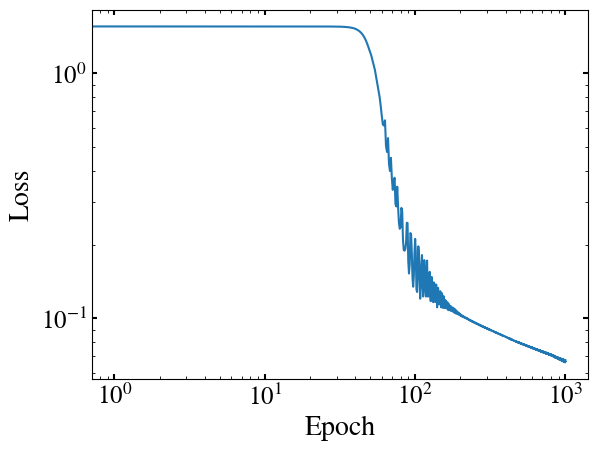

In [7]:
plt.loglog(model.loss_list)
plt.xlabel('Epoch', fontsize=20)
plt.ylabel('Loss', fontsize=20)

Text(0, 0.5, '$H_{\\text{target}}$')

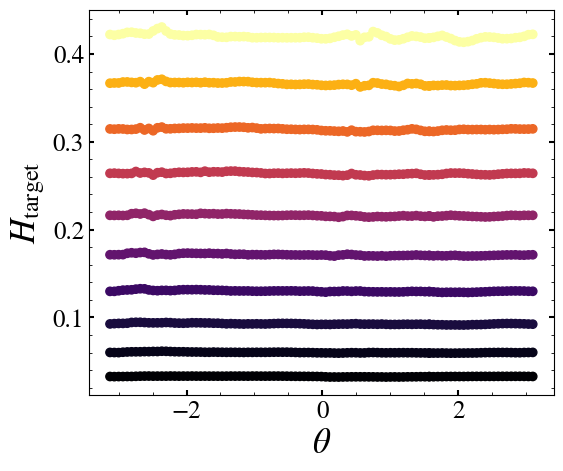

In [8]:
with torch.no_grad():
    transformed_ps = model.flow(guess_ps)
    newH = H(transformed_ps, targetPotential) # the energy calculated in the target potential

plt.figure(figsize=(6, 5))
plt.scatter(true_aa[...,0], newH, c=Htoy, cmap='inferno')
plt.xlabel('$\\theta$', fontsize=25)
plt.ylabel('$H_{\\text{target}}$', fontsize=25)

(np.float64(-1.1394216477870942),
 np.float64(1.1303127467632295),
 np.float64(-1.0079265981912613),
 np.float64(1.0020298510789871))

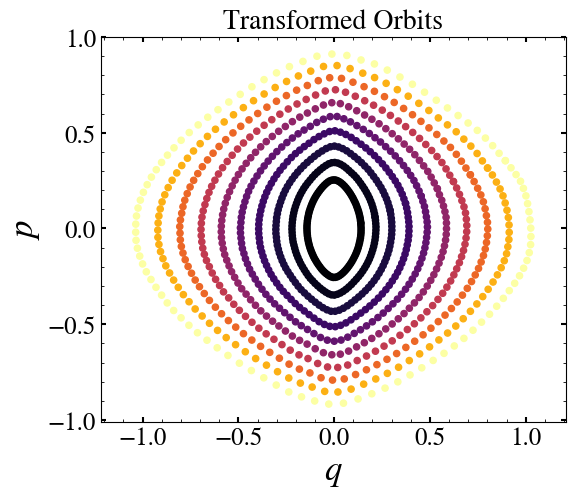

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(transformed_ps[...,0], transformed_ps[...,1], c=Htoy, s=20, cmap='inferno', zorder=5)
plt.xlabel('$q$', fontsize=25)
plt.ylabel('$p$', fontsize=25)
plt.title('Transformed Orbits', fontsize=20)
plt.axis('equal')

/tmp/ipykernel_1884670/2402192661.py:27: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4421.)
  plt.plot(*transformed_ps.T, c='k', lw=1.5, zorder=0, alpha=0.2)



(np.float64(-1.9585054993629456),
 np.float64(1.920040237903595),
 np.float64(-1.2390862166881562),
 np.float64(1.2018806397914887))

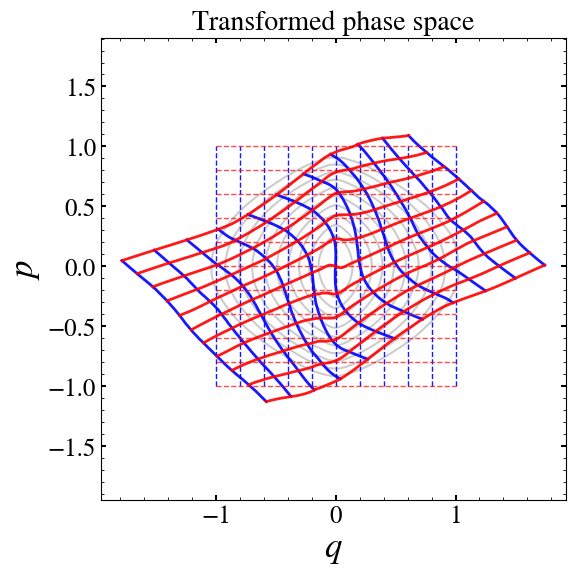

In [10]:
plt.figure(figsize=(6, 6))


# Create grid lines in original phase space and transform them
n_grid = 100
q_range = torch.linspace(-1.0, 1.0, n_grid)
p_range = torch.linspace(-1.0, 1.0, n_grid)

# Create multiple vertical and horizontal lines forming a grid
n_lines = 11
q_lines = torch.linspace(-1.0, 1.0, n_lines)
p_lines = torch.linspace(-1.0, 1.0, n_lines)

with torch.no_grad():
    for q_val in q_lines:
        vline = torch.stack([q_val.expand(n_grid), p_range], dim=-1).unsqueeze(0)
        
        transformed_vline = model.flow(vline).squeeze(0)
        plt.plot(vline[0, :, 0], vline[0, :, 1], color='blue', linewidth=1.0, alpha=0.9, linestyle='dashed')
        plt.plot(transformed_vline[:, 0], transformed_vline[:, 1], color='blue', linewidth=2.0, alpha=0.9)
    
    for p_val in p_lines:
        hline = torch.stack([q_range, p_val.expand(n_grid)], dim=-1).unsqueeze(0)
        transformed_hline = model.flow(hline).squeeze(0)
        plt.plot(hline[0, :, 0], hline[0, :, 1], color='red', linewidth=1.0, alpha=0.7, linestyle='dashed')
        plt.plot(transformed_hline[:, 0], transformed_hline[:, 1], color='red', linewidth=2.0, alpha=0.9)
plt.plot(*transformed_ps.T, c='k', lw=1.5, zorder=0, alpha=0.2)
plt.xlabel('$q$', fontsize=25)
plt.ylabel('$p$', fontsize=25)
plt.title('Transformed phase space', fontsize=20)
plt.axis('equal')

In [11]:
import astropy.units as u
ro = 8.0 * u.kpc
vo = 220.0 * u.km / u.s
n_orbits = 100
n_angles = 1000
omega0 = 1.5
z_max_0 = 0.005/ro.value#(2.0 * u.kpc).value
z_max_1 = 1.5/ro.value#((80.1 * u.pc).to(u.kpc)).value

ex_ps, ex_aa = generate_sho_orbits(n_orbits=n_orbits, omega=omega0, t_end = 2*torch.pi / omega0, n_steps=n_angles, r_bounds=torch.tensor([z_max_1, z_max_0]))
ex_model_ps = model.aa_to_ps(ex_aa.to(torch.float32))
z_max_list = ex_model_ps[:,0][:,0]*ro.value

<>:10: SyntaxWarning: invalid escape sequence '\l'

<>:10: SyntaxWarning: invalid escape sequence '\l'

/tmp/ipykernel_1884670/655363020.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$ \log_{10}\\left (\\frac{\Delta E}{\langle E \\rangle} \\right )$', fontsize=25)



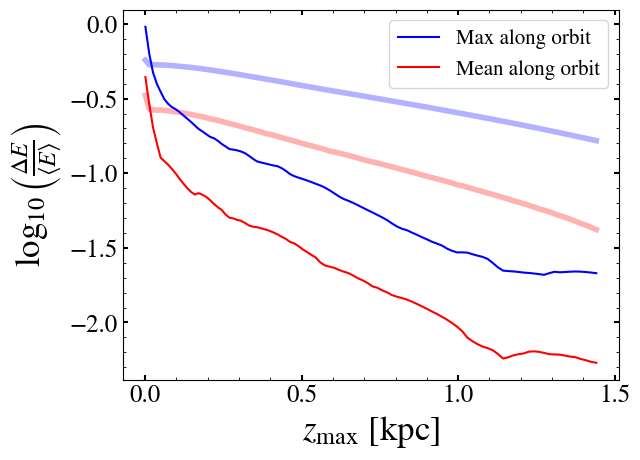

In [12]:
from orbitflows.util import max_error_along_orbs, mean_error_along_orbs

plt.plot(z_max_list.detach(), max_error_along_orbs(H(ex_ps, model.targetPotential)).detach(), c='b', alpha=0.3, lw=4)
plt.plot(z_max_list.detach(), mean_error_along_orbs(H(ex_ps, model.targetPotential)).detach(),  c='r', alpha=0.3, lw=4)

plt.plot(z_max_list.detach(), max_error_along_orbs(H(ex_model_ps, model.targetPotential)).detach(), label='Max along orbit', c='b')
plt.plot(z_max_list.detach(), mean_error_along_orbs(H(ex_model_ps, model.targetPotential)).detach(), label='Mean along orbit', c='r')

plt.xlabel('$z_{\\text{max}}$ [kpc]', fontsize=25)
plt.ylabel('$ \log_{10}\\left (\\frac{\Delta E}{\langle E \\rangle} \\right )$', fontsize=25)
plt.legend(fontsize=15)

The thick lines are from before training.